# EmployeeEdge — Exploratory Data Analysis (EDA)

## What is EDA?
Before building any model, we need to **understand our data**. EDA answers:
- What does each feature look like?
- How imbalanced is attrition (Yes vs No)?
- Which features are related to employees leaving?
- Are there outliers, missing values, or strange patterns?

**This notebook is Step 2 of the EmployeeEdge project.**

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Load the Dataset

The dataset lives in `../data/WA_Fn-UseC_-HR-Employee-Attrition.csv`. We load it into a **pandas DataFrame** — think of it as an Excel table you can work with in Python.

**What to look for:** Does the file load? How many rows and columns?

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset loaded: 1470 rows x 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


---
## 3. First Look — Shape, Data Types, Column Names

**Why this matters:**
- `dtypes` tells us which columns are numbers vs text (we'll need to encode text later)
- Constant columns (same value for every row) can be dropped — they carry zero information

**What to look for:** Any columns with only 1 unique value? Those are useless for prediction.

In [3]:
print('=== SHAPE ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\n=== DATA TYPES ===')
print(df.dtypes.value_counts())

print('\n=== ALL COLUMNS ===')
for i, col in enumerate(df.columns, 1):
    n_unique = df[col].nunique()
    print(f'{i:2d}. {col:30s}  type={str(df[col].dtype):8s}  unique={n_unique}')

=== SHAPE ===
Rows: 1470, Columns: 35

=== DATA TYPES ===
int64    26
str       9
Name: count, dtype: int64

=== ALL COLUMNS ===
 1. Age                             type=int64     unique=43
 2. Attrition                       type=str       unique=2
 3. BusinessTravel                  type=str       unique=3
 4. DailyRate                       type=int64     unique=886
 5. Department                      type=str       unique=3
 6. DistanceFromHome                type=int64     unique=29
 7. Education                       type=int64     unique=5
 8. EducationField                  type=str       unique=6
 9. EmployeeCount                   type=int64     unique=1
10. EmployeeNumber                  type=int64     unique=1470
11. EnvironmentSatisfaction         type=int64     unique=4
12. Gender                          type=str       unique=2
13. HourlyRate                      type=int64     unique=71
14. JobInvolvement                  type=int64     unique=4
15. JobLevel           

---
## 4. Statistical Summary

For every numerical column, `describe()` shows:
- **mean**: average value
- **std**: how spread out the values are
- **min/max**: range of values
- **25%/50%/75%**: percentiles (where the data clusters)

**What to look for:** Suspiciously large or small values that might be errors.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


---
## 5. Missing Values & Duplicates

**Why this matters:**
- Missing values break most ML models — we need to handle them (fill or drop)
- Duplicates skew results — same employee counted twice = wrong patterns
- **Constant columns** (like `EmployeeCount` = 1 for everyone) add noise — we drop them

**What to look for:** Any non-zero missing count? Any duplicates? Which columns are constant?

In [5]:
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('No missing values found!')
else:
    print(missing[missing > 0].sort_values(ascending=False))

print(f'\n=== DUPLICATES ===')
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')

print(f'\n=== CONSTANT COLUMNS (same value for every row) ===')
for col in df.columns:
    if df[col].nunique() == 1:
        print(f'  {col:30s} = {df[col].unique()[0]}')

print(f'\n=== TARGET COLUMN: Attrition ===')
print(df['Attrition'].value_counts())

=== MISSING VALUES ===
No missing values found!

=== DUPLICATES ===
Duplicate rows: 0

=== CONSTANT COLUMNS (same value for every row) ===
  EmployeeCount                  = 1
  Over18                         = Y
  StandardHours                  = 80

=== TARGET COLUMN: Attrition ===
Attrition
No     1233
Yes     237
Name: count, dtype: int64


---
## 6. Target Variable Analysis — How Imbalanced Is Attrition?

**The most important question in our project:** How many employees left vs stayed?

In real HR data, attrition is usually **imbalanced** — most people stay, only ~15-20% leave. This matters because:
- A dumb model that always predicts "No" would be 80%+ accurate but useless
- We'll need to handle this imbalance during modeling (class weights, SMOTE, etc.)

**What to look for:** The exact percentage of employees who left.

In [6]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print('=== ATTRITION DISTRIBUTION ===')
print(f'No (Stayed):  {attrition_counts["No"]:>5d}  ({attrition_pct["No"]:.1f}%)')
print(f'Yes (Left):   {attrition_counts["Yes"]:>5d}  ({attrition_pct["Yes"]:.1f}%)')
print(f'\nDataset is IMBALANCED: only {attrition_pct["Yes"]:.1f}% left.')
print(f'A model that always predicts "No" would get ~{attrition_pct["No"]:.1f}% accuracy — that is our baseline to beat.')

=== ATTRITION DISTRIBUTION ===
No (Stayed):   1233  (83.9%)
Yes (Left):     237  (16.1%)

Dataset is IMBALANCED: only 16.1% left.
A model that always predicts "No" would get ~83.9% accuracy — that is our baseline to beat.


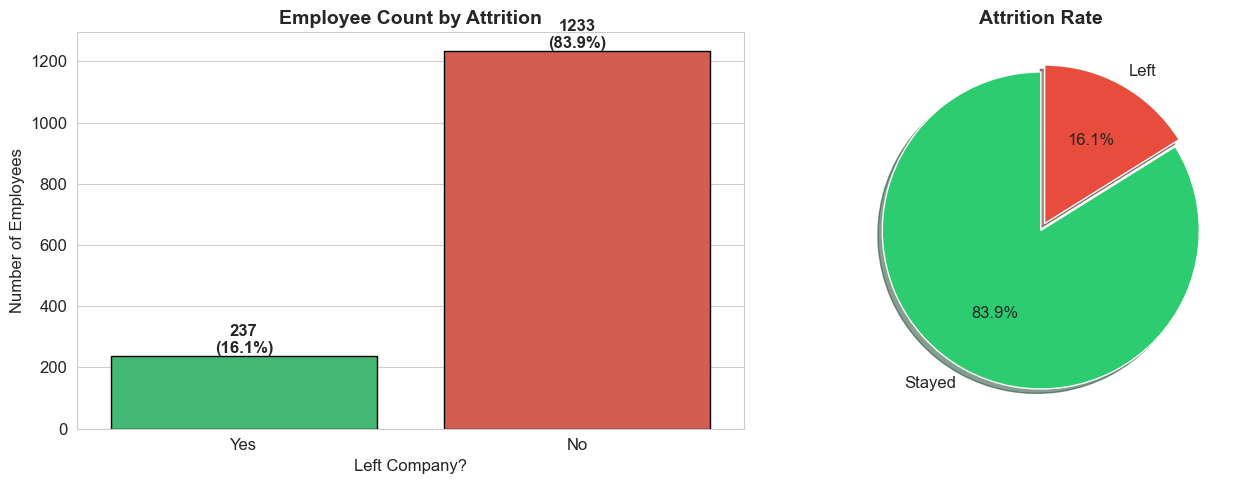

Plot saved to outputs/plots/01_attrition_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']

sns.countplot(x='Attrition', data=df, palette=colors, ax=axes[0], edgecolor='black')
axes[0].set_title('Employee Count by Attrition', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Left Company?')
axes[0].set_ylabel('Number of Employees')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

axes[1].pie(attrition_counts.values, labels=['Stayed', 'Left'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05), shadow=True)
axes[1].set_title('Attrition Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/01_attrition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/plots/01_attrition_distribution.png')

---
## 7. Numerical Feature Distributions

We look at the shape of every numerical column to understand:
- Are values normally distributed (bell curve) or skewed?
- Are there outliers?
- Which features have the most variation?

**What to look for:** Skewed features might need log transformation later.

Numerical features: 24
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


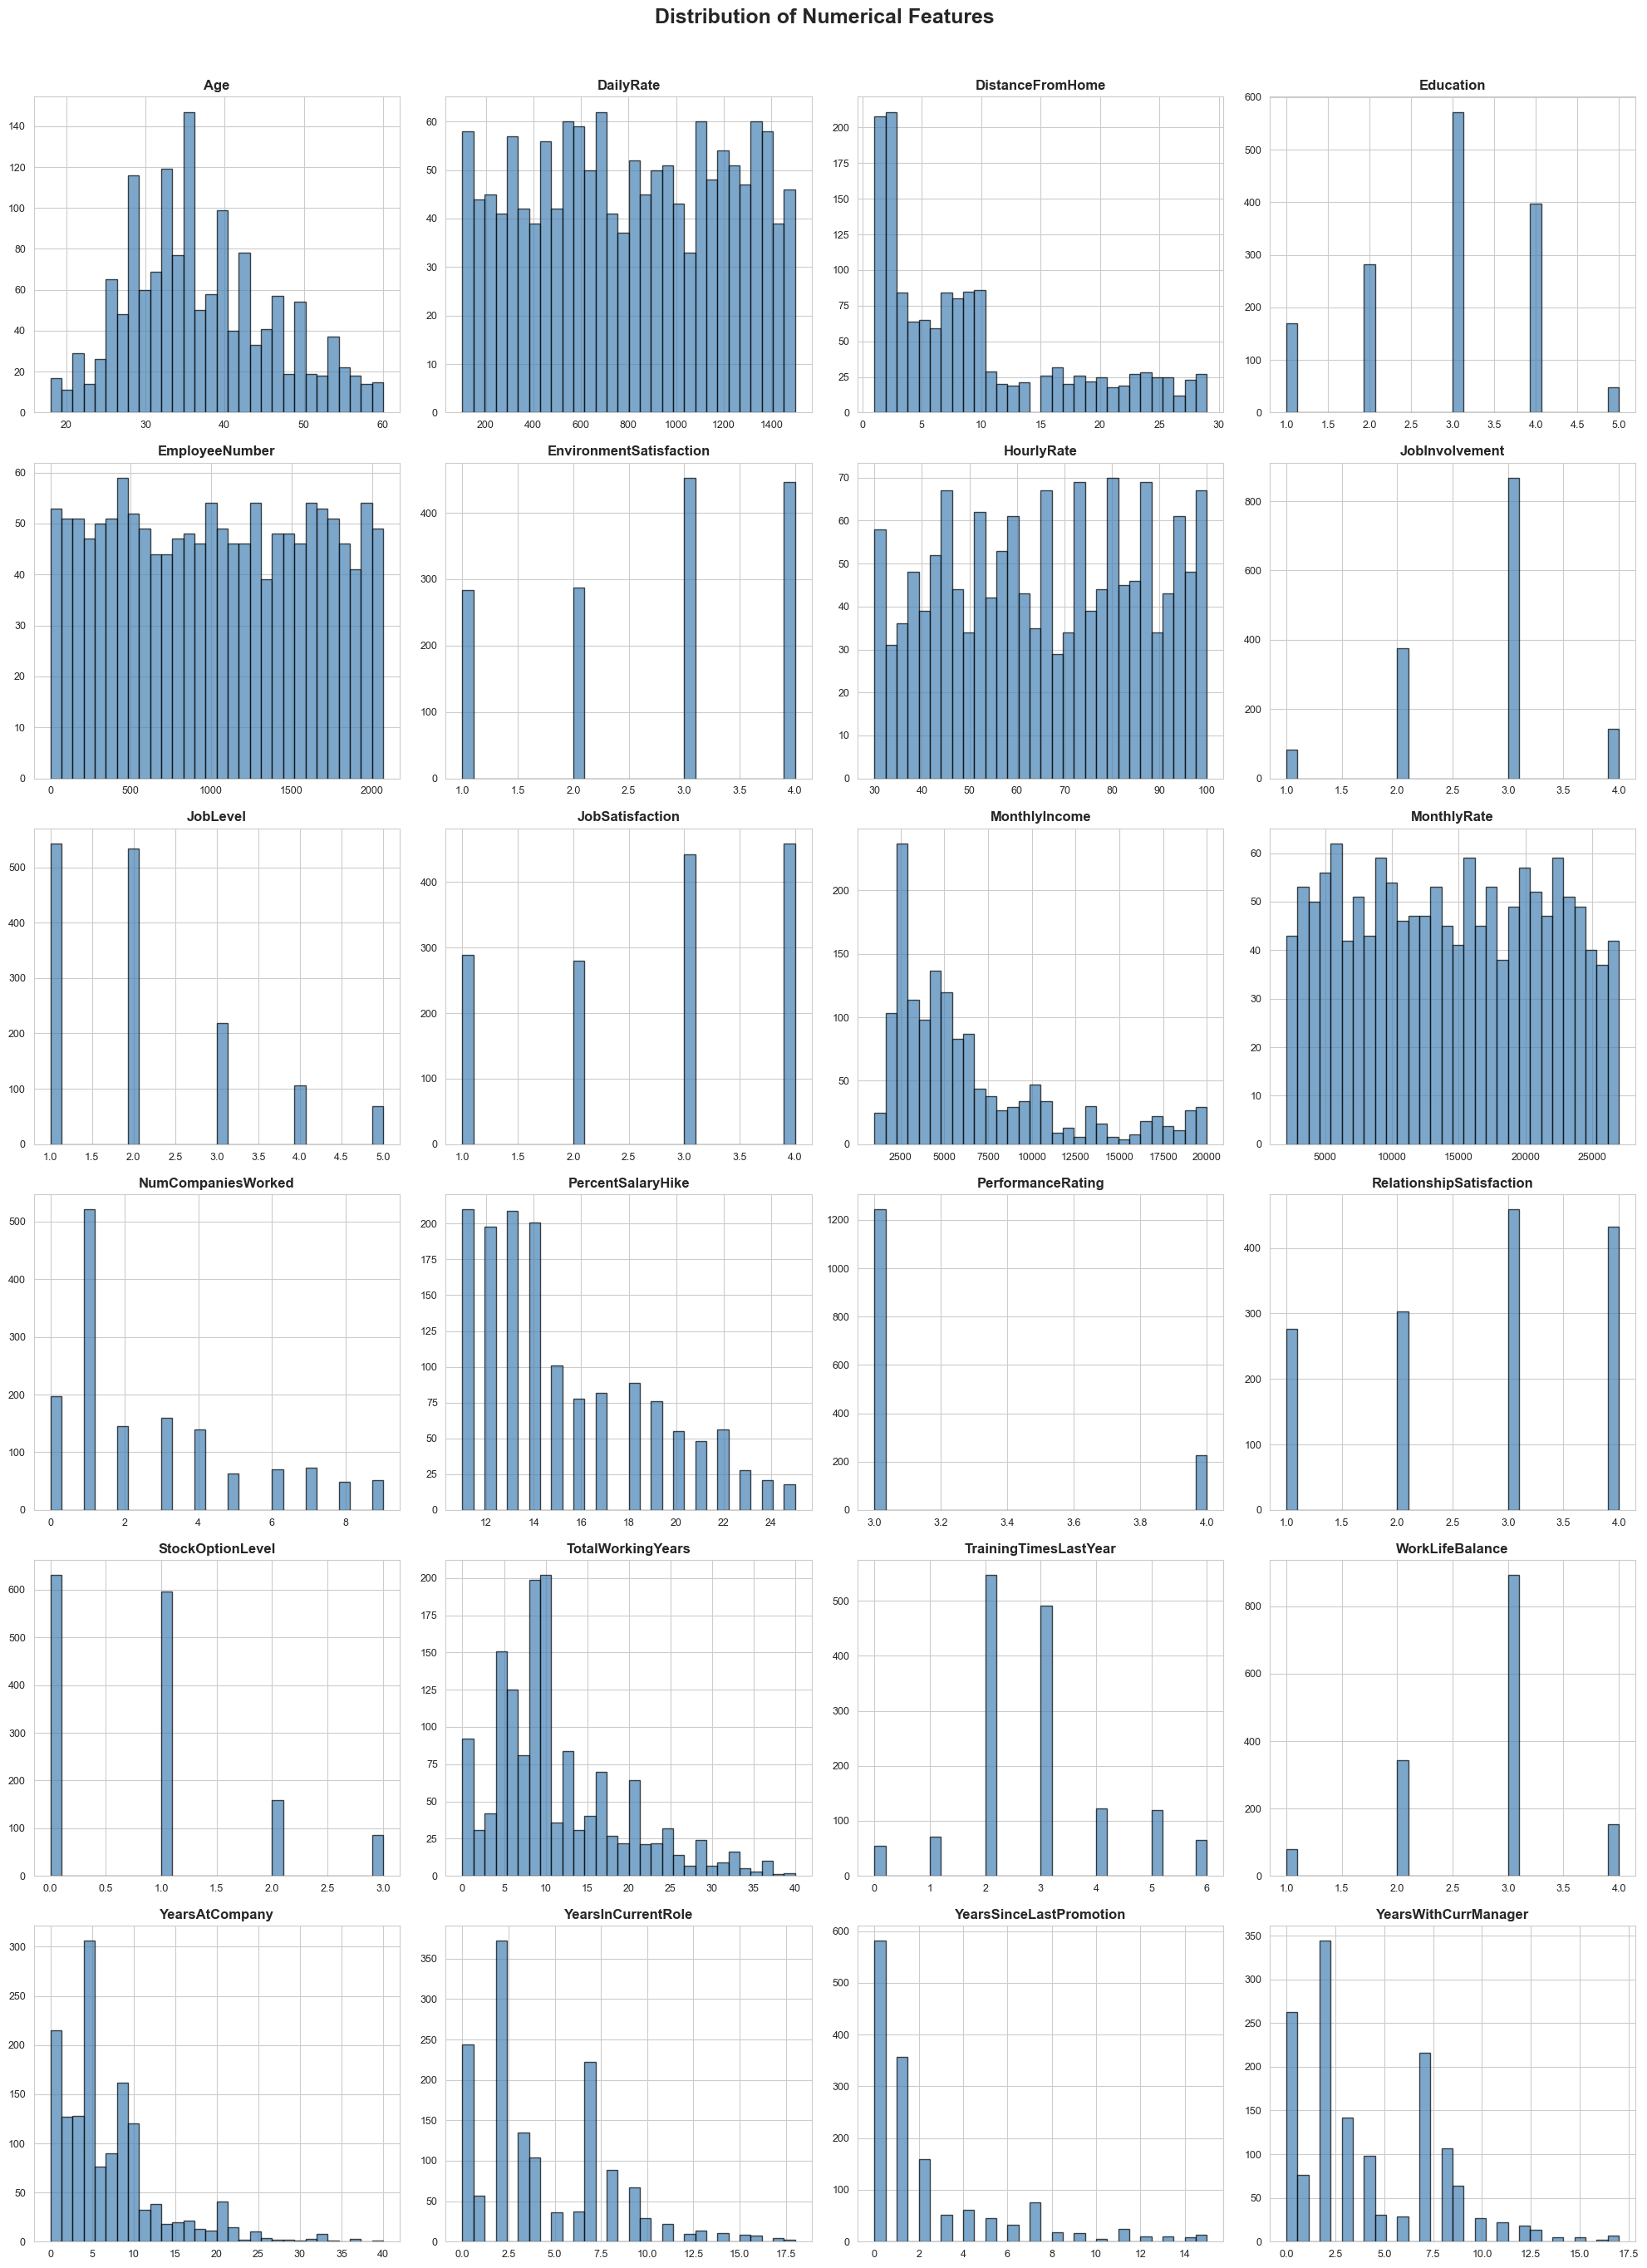

Plot saved to outputs/plots/02_numerical_distributions.png


In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [col for col in numerical_cols if df[col].nunique() > 1]

print(f'Numerical features: {len(numerical_cols)}')
print(numerical_cols)

n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4.5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].tick_params(labelsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/plots/02_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/plots/02_numerical_distributions.png')

---
## 8. Key Numerical Features vs Attrition (Boxplots)

Boxplots compare the distribution of a feature for employees who stayed vs left.

**What to look for:**
- If the boxes are at **different heights** -> the feature is likely important for prediction
- If boxes overlap heavily -> the feature may not help much

**Hypothesis:** Employees who left are likely younger, lower-paid, and closer to the start of their tenure.

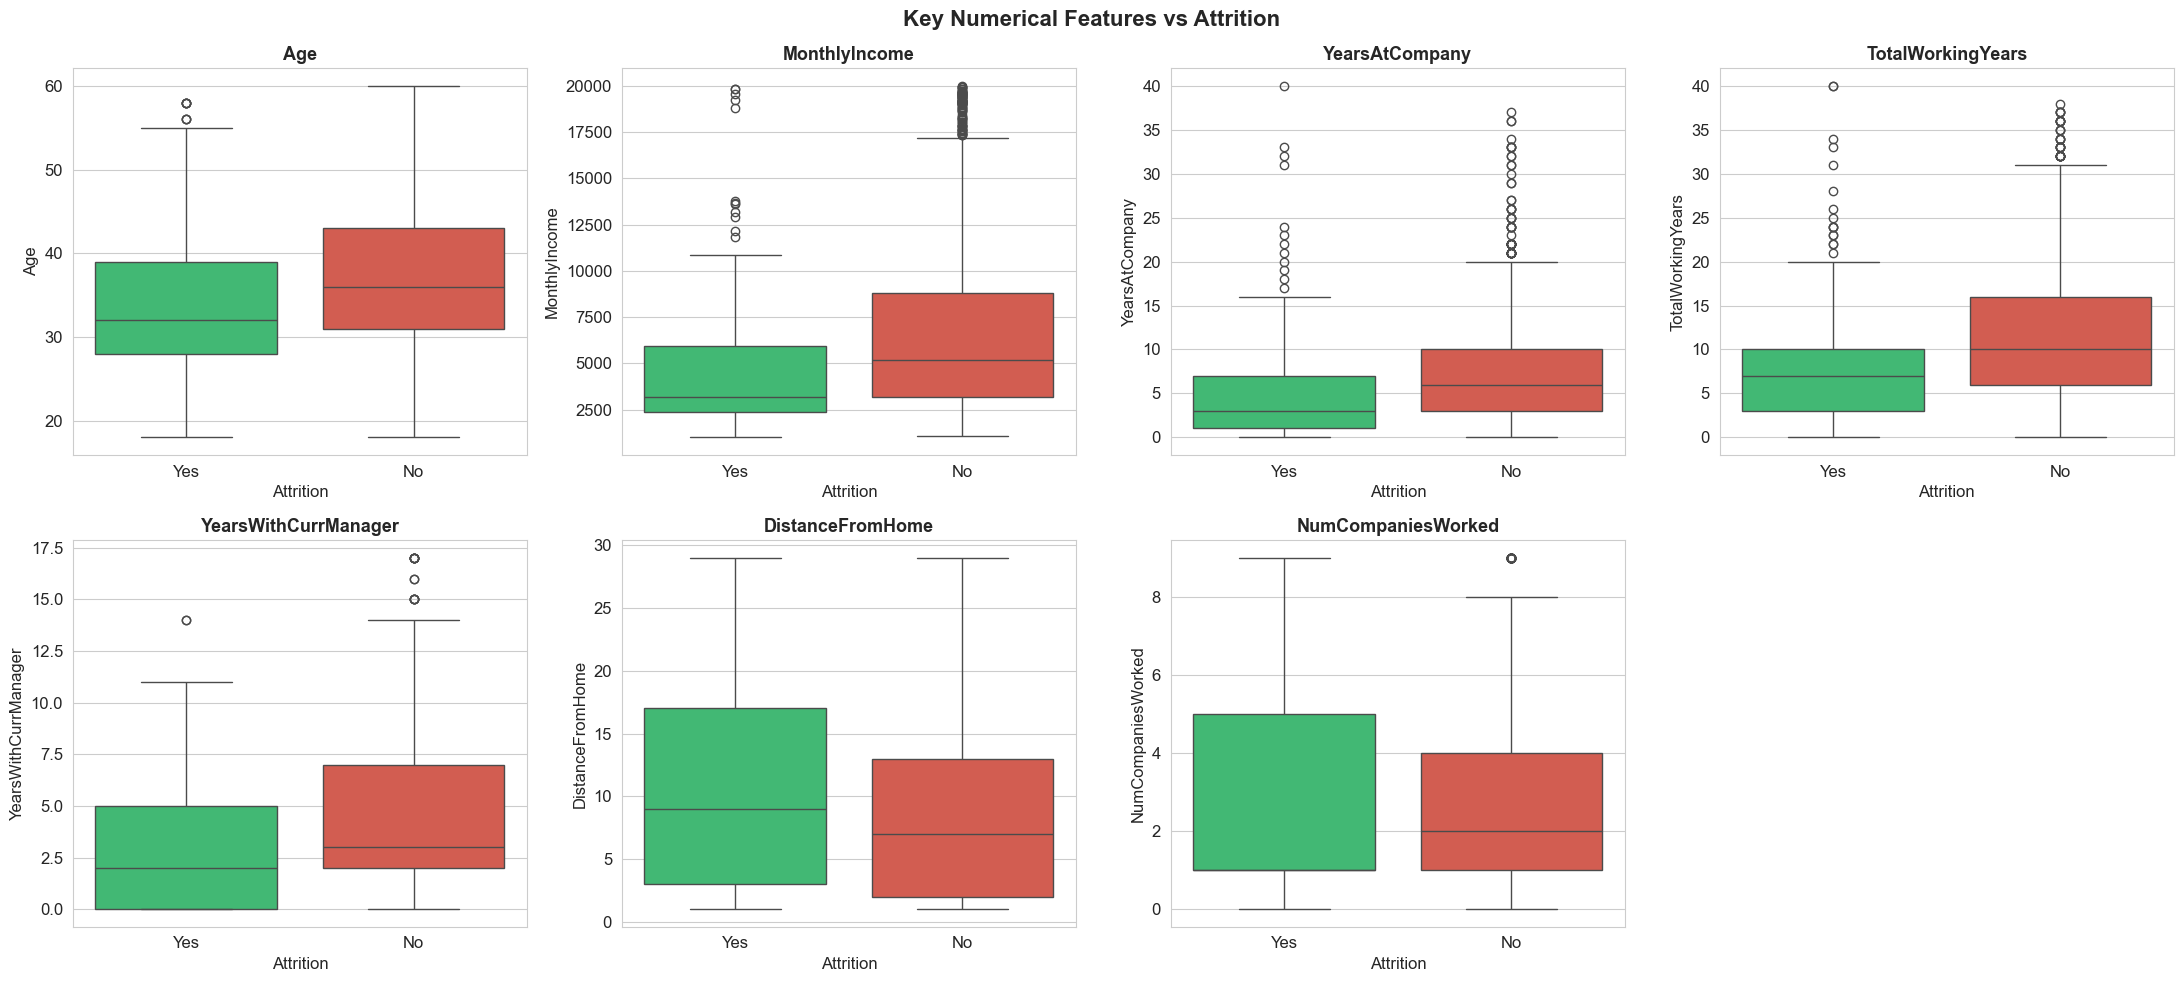

Plot saved to outputs/plots/03_numerical_vs_attrition.png


In [9]:
key_numerical = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears',
                 'YearsWithCurrManager', 'DistanceFromHome', 'NumCompaniesWorked']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(key_numerical):
    sns.boxplot(x='Attrition', y=col, data=df, palette=colors, ax=axes[i])
    axes[i].set_title(col, fontsize=13, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Key Numerical Features vs Attrition', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/03_numerical_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/plots/03_numerical_vs_attrition.png')

---
## 9. Categorical Features vs Attrition

For each text column (department, job role, overtime, etc.), we calculate:
**What % of employees in each category LEFT?**

This is the **attrition rate per group** — directly useful for business insights.

**What to look for:**
- Which job roles have the highest attrition?
- Does overtime dramatically increase attrition?
- Which department is bleeding people?

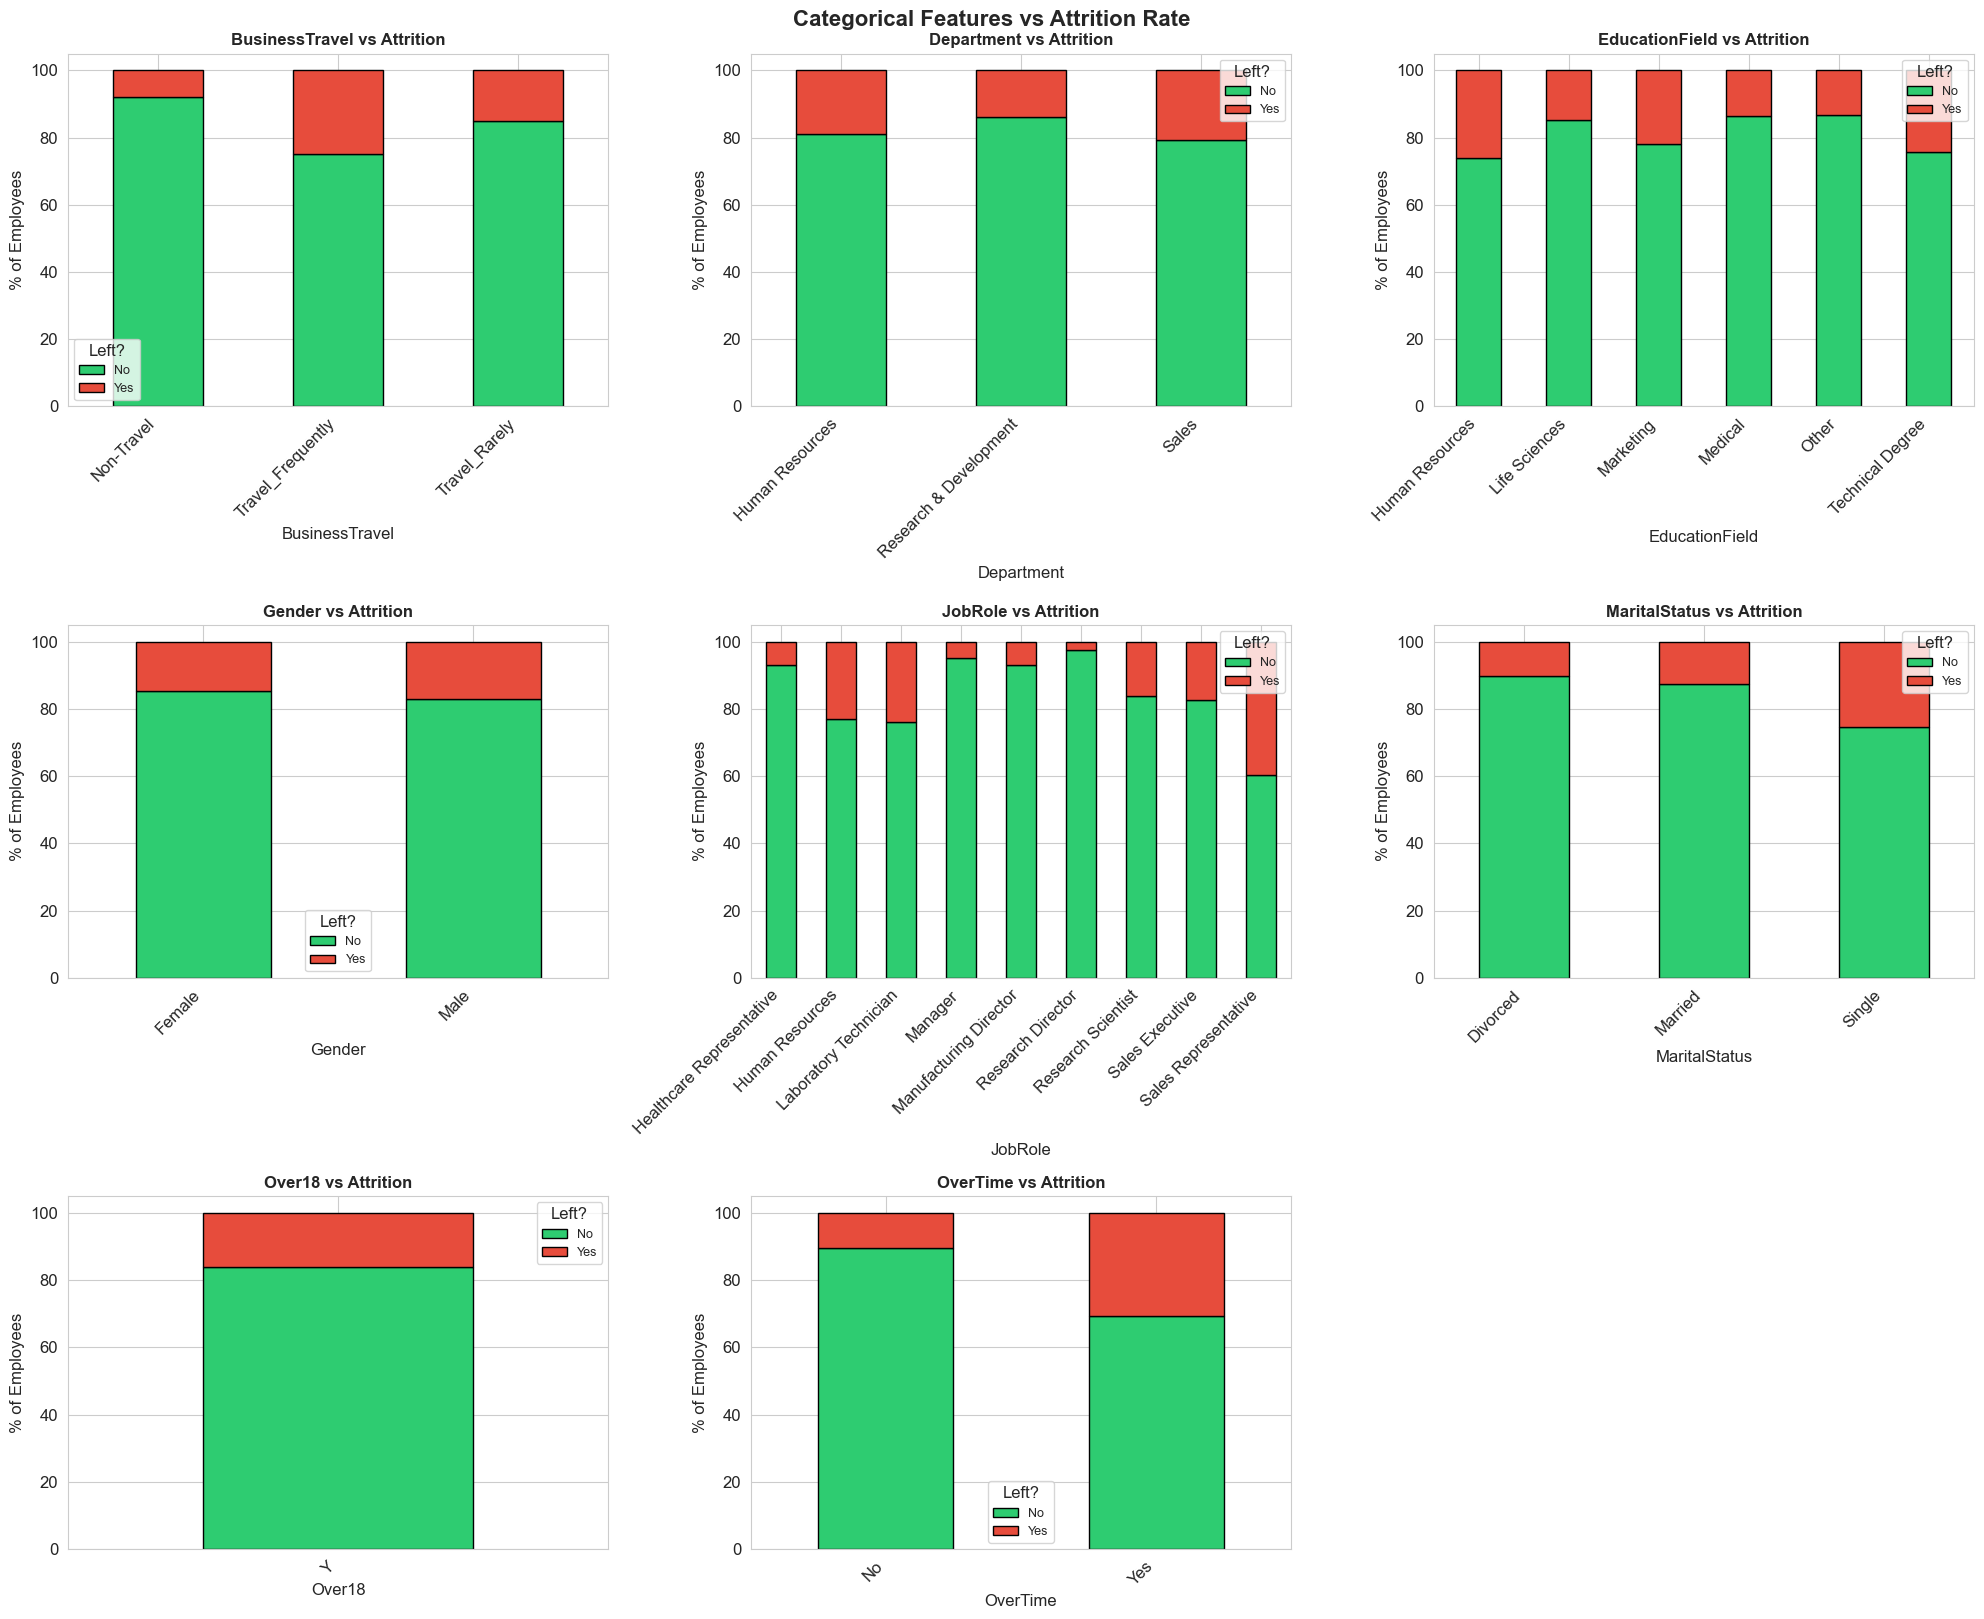

Plot saved to outputs/plots/04_categorical_vs_attrition.png


In [10]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Attrition')

n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5.5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['Attrition'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, color=colors, ax=axes[i], edgecolor='black')
    axes[i].set_title(f'{col} vs Attrition', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('% of Employees')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].legend(title='Left?', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Attrition Rate', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/04_categorical_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/plots/04_categorical_vs_attrition.png')

---
## 10. Correlation Heatmap

Correlation measures how two numerical features move together:
- **+1.0**: perfectly correlated (both go up together)
- **0.0**: no relationship
- **-1.0**: inversely correlated (one goes up, the other goes down)

**Why this matters:**
- Highly correlated features (e.g., `MonthlyIncome` and `JobLevel`) carry duplicate information
- We may want to drop one to reduce redundancy

**What to look for:** Dark red/blue cells = strong correlations.

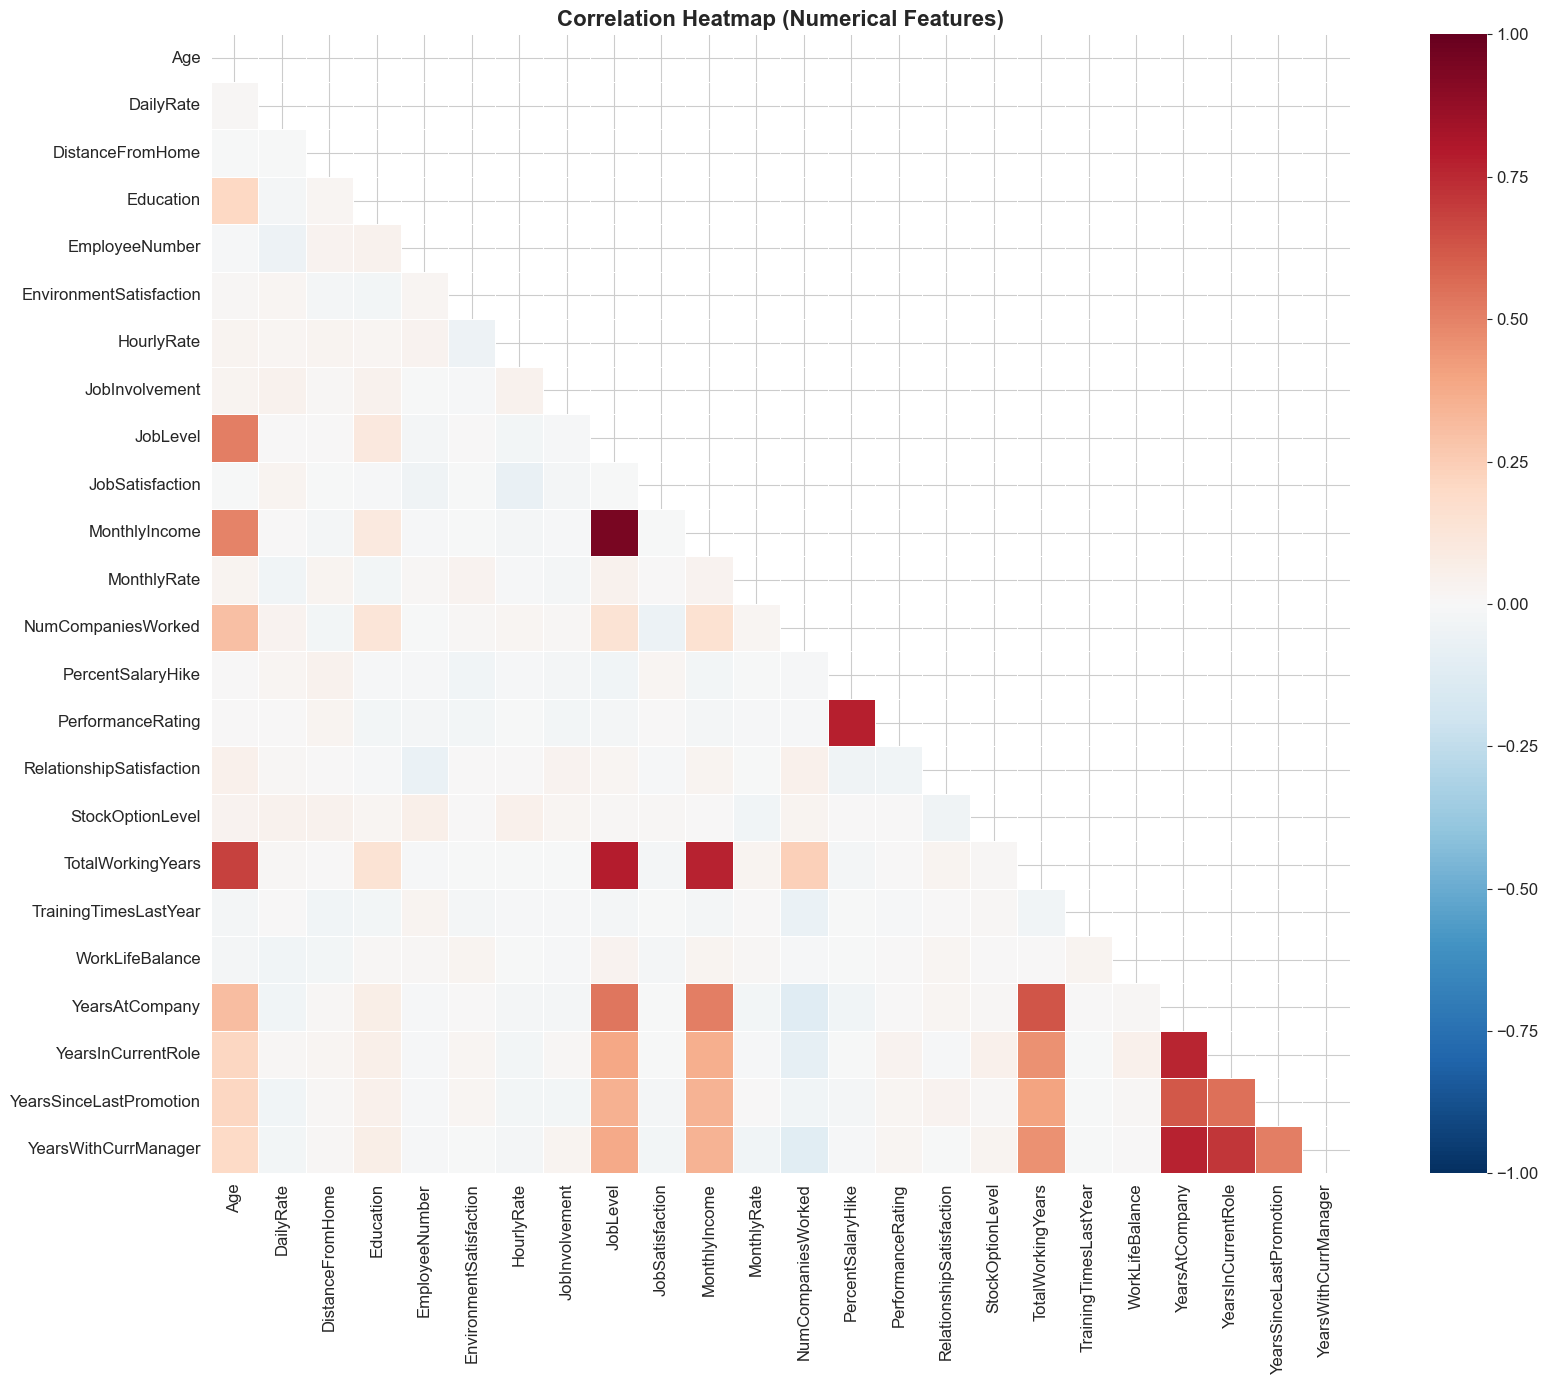

Plot saved to outputs/plots/05_correlation_heatmap.png


In [11]:
plt.figure(figsize=(18, 14))
corr = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Numerical Features)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/plots/05_correlation_heatmap.png')

---
## 11. Feature Correlation with Attrition

Now we encode Attrition (Yes=1, No=0) and compute each feature's correlation with it.

**What to look for:**
- **Negative correlation**: feature goes UP -> attrition goes DOWN (higher income = less likely to leave)
- **Positive correlation**: feature goes UP -> attrition goes UP (more overtime = more likely to leave)

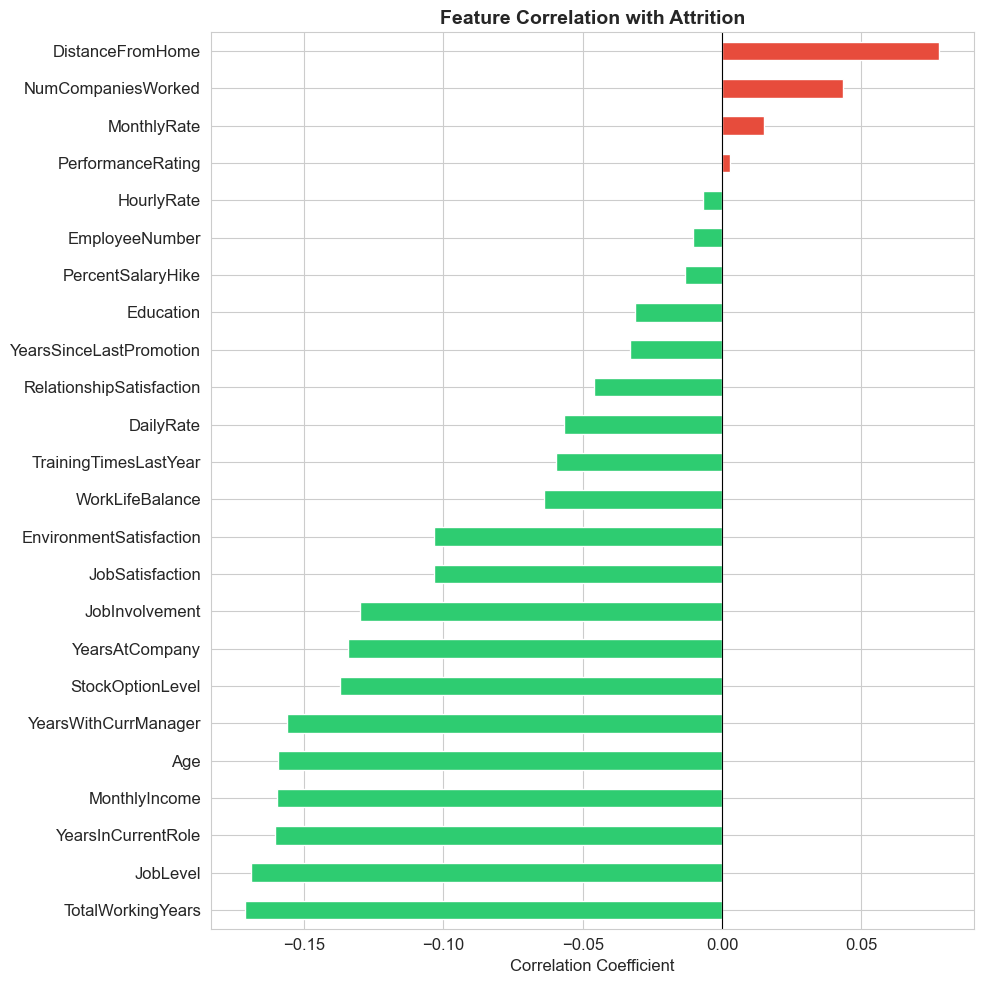

Plot saved to outputs/plots/06_correlation_with_attrition.png

=== TOP POSITIVE CORRELATIONS (more of this = MORE attrition) ===
HourlyRate           -0.006846
PerformanceRating     0.002889
MonthlyRate           0.015170
NumCompaniesWorked    0.043494
DistanceFromHome      0.077924
Name: Attrition, dtype: float64

=== TOP NEGATIVE CORRELATIONS (more of this = LESS attrition) ===
TotalWorkingYears    -0.171063
JobLevel             -0.169105
YearsInCurrentRole   -0.160545
MonthlyIncome        -0.159840
Age                  -0.159205
Name: Attrition, dtype: float64


In [12]:
df_encoded = df.copy()
df_encoded['Attrition'] = df_encoded['Attrition'].map({'Yes': 1, 'No': 0})

corr_with_target = df_encoded[numerical_cols + ['Attrition']].corr()['Attrition'].drop('Attrition').sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
corr_with_target.plot(kind='barh', ax=ax,
                      color=['#e74c3c' if v > 0 else '#2ecc71' for v in corr_with_target.values])
ax.set_title('Feature Correlation with Attrition', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../outputs/plots/06_correlation_with_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/plots/06_correlation_with_attrition.png')

print('\n=== TOP POSITIVE CORRELATIONS (more of this = MORE attrition) ===')
print(corr_with_target.tail(5))
print('\n=== TOP NEGATIVE CORRELATIONS (more of this = LESS attrition) ===')
print(corr_with_target.head(5))

---
## 12. Attrition Rate by Key Categories

Let's zoom into the most business-relevant breakdowns:
- **Overtime**: Does working extra hours drive people away?
- **Job Role**: Are sales reps or lab techs leaving faster?
- **Department**: Which department has the highest turnover?

**What to look for:** The exact attrition rate per group — this becomes the business story.

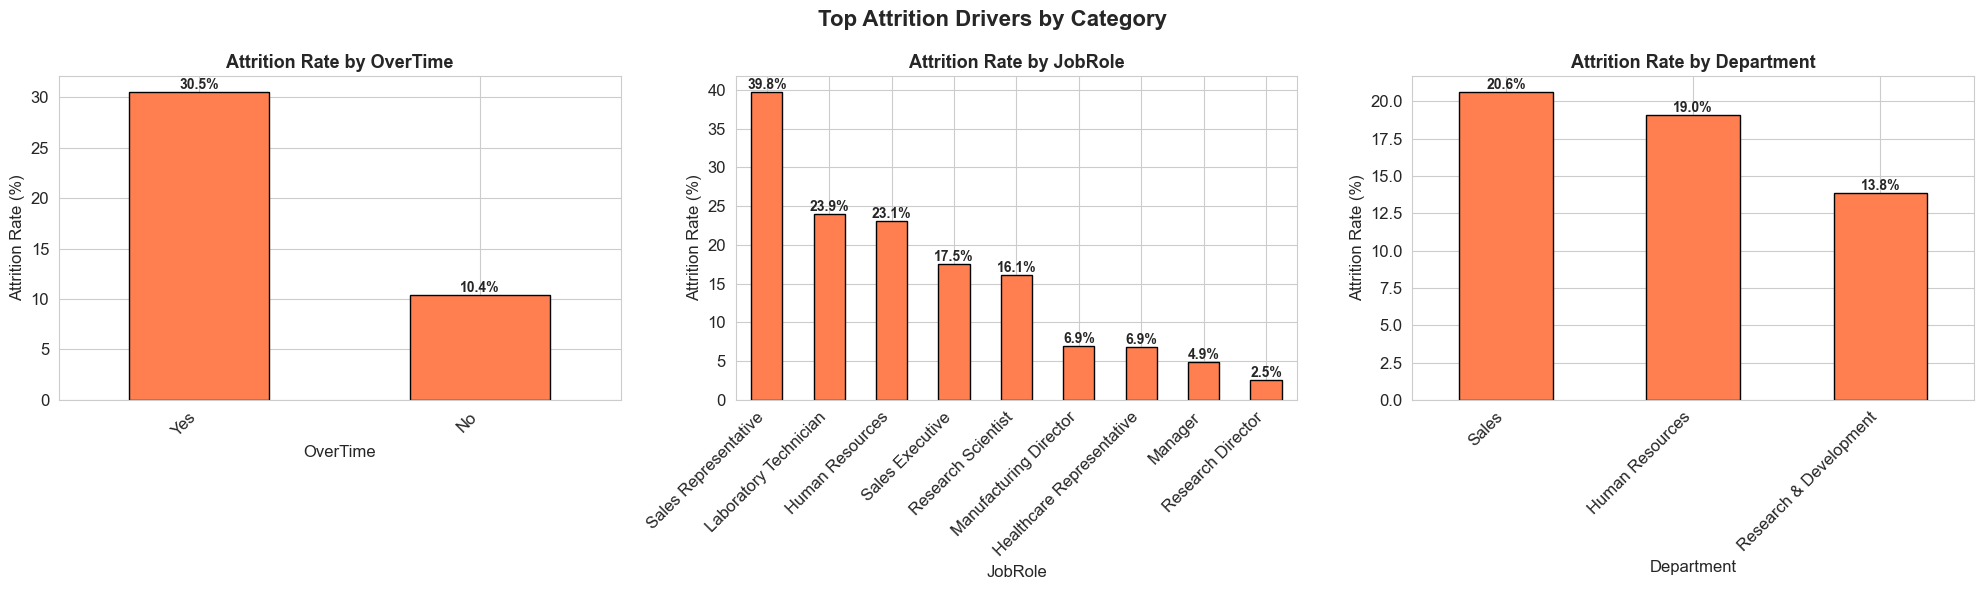

Plot saved to outputs/plots/07_attrition_rate_by_category.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(['OverTime', 'JobRole', 'Department']):
    rate = df.groupby(col)['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    rate.plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
    axes[i].set_title(f'Attrition Rate by {col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1f}%',
                         (p.get_x() + p.get_width()/2., p.get_height()),
                         ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Top Attrition Drivers by Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/07_attrition_rate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/plots/07_attrition_rate_by_category.png')

---
## 13. Key Findings Summary

Based on this EDA, here is what we know going into modeling:

### Data Quality
- **No missing values** — clean dataset
- **3 constant columns** to drop: `EmployeeCount`, `Over18`, `StandardHours`
- **`EmployeeNumber`** is an ID — drop it (not predictive)

### Target Variable
- **~16% attrition rate** — significantly imbalanced
- Dummy model baseline: always predict "No" = ~84% accuracy
- We need metrics beyond accuracy (precision, recall, F1, AUC-ROC)

### Top Attrition Drivers (from EDA)
1. **OverTime** = Yes -> much higher attrition
2. **Low MonthlyIncome** -> higher attrition
3. **Single marital status** -> higher attrition
4. **Young age** -> higher attrition
5. **Few years at company / with current manager** -> higher attrition

### Next Steps (Step 3: Preprocessing)
1. Drop constant columns + EmployeeNumber
2. Encode categorical variables (one-hot / label encoding)
3. Handle class imbalance (SMOTE or class weights)
4. Feature engineering (e.g., income bins, tenure categories)
5. Train/test split with stratification